Step 1: Install Required Libraries

In [1]:
!pip install -q google-generativeai pillow

Step 2: Import Required Libraries

In [2]:
import google.generativeai as genai
from PIL import Image
from google.colab import files
import os

/usr/local/lib/python3.13/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


Step 3: Configure Gemini API

In [ ]:
import getpass

api_key = getpass.getpass("Enter your Gemini API Key:")
genai.configure(api_key=api_key)

AQ.Ab8RN6Lg_OeGWvI29Ct1wQo1sv9XIeSPtjuMoHOuynf2xkg0kQ··········


Step 4: Upload an Image

In [4]:
uploaded = files.upload()

Saving 2.webp to 2.webp


Step 5: Display the Uploaded Image

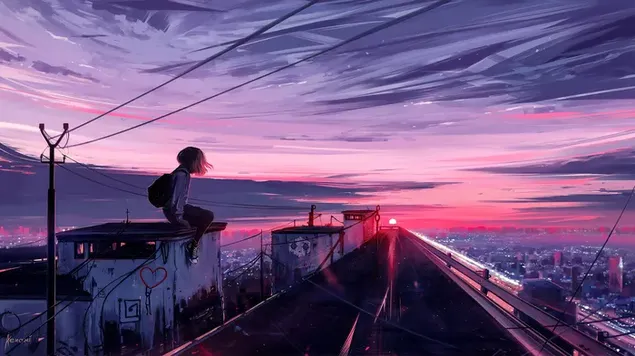

In [5]:
image_path = list(uploaded.keys())[0]

image = Image.open(image_path)
display(image)

Step 6: Load the Gemini Vision Model

In [11]:
!pip install -q -U google-genai

In [12]:
from google import genai

client = genai.Client(api_key=api_key)

Step 7: Generate a Basic Image Caption

In [15]:
response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[prompt, image]
)

print("Generated Caption:")
print(response.text)

Generated Caption:
A lone girl with a backpack sits on a high rooftop, watching the sunset over a sprawling city painted in shades of purple and pink.


Step 8: Generate 3 Different Captions

In [16]:
prompt = """
Analyze this image and generate 3 different captions:

1. Short Caption
2. Professional Caption
3. Creative Social Media Caption

Also provide 5 relevant hashtags.

Keep the captions natural, clear, and engaging.
"""

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[prompt, image]
)

print(response.text)

Here are the requested captions and hashtags based on the image:

1. **Short Caption**
   Lost in the twilight glow.

2. **Professional Caption**
   An atmospheric digital illustration capturing a quiet moment above the city skyline at dusk.

3. **Creative Social Media Caption**
   Where the noise of the city fades into a canvas of pinks and purples. Sometimes, you just need a quiet moment above the world to watch the sun go down. 🌆✨

**Hashtags:**
#DigitalArt #Cityscape #SunsetVibes #AnimeAesthetic #UrbanMelancholy


Step 9: Create a Professional Output Format

In [17]:
print("=" * 60)
print("        AI IMAGE CAPTION GENERATOR")
print("=" * 60)

print("\nGenerated AI Captions:")
print("-" * 60)
print(response.text)

print("\n" + "=" * 60)
print("        Caption Generation Completed")
print("=" * 60)

        AI IMAGE CAPTION GENERATOR

Generated AI Captions:
------------------------------------------------------------
Here are the requested captions and hashtags based on the image:

1. **Short Caption**
   Lost in the twilight glow.

2. **Professional Caption**
   An atmospheric digital illustration capturing a quiet moment above the city skyline at dusk.

3. **Creative Social Media Caption**
   Where the noise of the city fades into a canvas of pinks and purples. Sometimes, you just need a quiet moment above the world to watch the sun go down. 🌆✨

**Hashtags:**
#DigitalArt #Cityscape #SunsetVibes #AnimeAesthetic #UrbanMelancholy

        Caption Generation Completed


Step 10: Add Caption Style Selection

In [18]:
caption_style = input(
    "Enter caption style (Short / Professional / Creative): "
)

prompt = f"""
Analyze this image and generate one {caption_style} caption.

Make it natural, clear, and engaging.
Do not add explanations.
"""

response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[prompt, image]
)

print("\nSelected Style:", caption_style)
print("Generated Caption:")
print(response.text)

Enter caption style (Short / Professional / Creative): Professional

Selected Style: Professional
Generated Caption:
Lost in thought as the city lights begin to flicker beneath a breathtaking twilight sky.


Step 11: Generate Hashtags

In [19]:
hashtag_prompt = f"""
Based on this image, generate 8 relevant hashtags
for social media.

Rules:
- Use simple and relevant hashtags
- Do not use numbering
- Keep them professional
- Return only hashtags
"""

hashtag_response = client.models.generate_content(
    model="gemini-3.5-flash-lite",
    contents=[hashtag_prompt, image]
)

print("Generated Hashtags:")
print(hashtag_response.text)

Generated Hashtags:
#AnimeArt
#DigitalArt
#SunsetVibes
#Cityscape
#Melancholy
#Artwork
#Mood
#Illustration


Step 12: Create a Complete Final Output

In [20]:
print("=" * 60)
print("           AI IMAGE CAPTION GENERATOR")
print("=" * 60)

print("\n📌 Caption Style:")
print(caption_style)

print("\n📝 Generated Caption:")
print(response.text)

print("\n🏷️ Generated Hashtags:")
print(hashtag_response.text)

print("\n" + "=" * 60)
print("             AI ANALYSIS COMPLETE")
print("=" * 60)

           AI IMAGE CAPTION GENERATOR

📌 Caption Style:
Professional

📝 Generated Caption:
Lost in thought as the city lights begin to flicker beneath a breathtaking twilight sky.

🏷️ Generated Hashtags:
#AnimeArt
#DigitalArt
#SunsetVibes
#Cityscape
#Melancholy
#Artwork
#Mood
#Illustration

             AI ANALYSIS COMPLETE


Step 13: Add a Simple User-Friendly Interface

In [21]:
import ipywidgets as widgets
from IPython.display import display

style_dropdown = widgets.Dropdown(
    options=["Short", "Professional", "Creative"],
    value="Professional",
    description="Style:"
)

generate_button = widgets.Button(
    description="Generate Caption"
)

output = widgets.Output()

display(style_dropdown, generate_button, output)

Dropdown(description='Style:', index=1, options=('Short', 'Professional', 'Creative'), value='Professional')

Button(description='Generate Caption', style=ButtonStyle())

Output()

Step 14: Connect the Generate Button

In [22]:
def generate_caption(b):
    with output:
        output.clear_output()

        selected_style = style_dropdown.value

        prompt = f"""
        Analyze this image and generate one {selected_style} caption.

        Make it natural, clear, meaningful, and engaging.
        Do not add explanations.
        """

        result = client.models.generate_content(
            model="gemini-3.5-flash-lite",
            contents=[prompt, image]
        )

        print("Caption Style:", selected_style)
        print("\nGenerated Caption:")
        print(result.text)


generate_button.on_click(generate_caption)

Step 15: Generate Hashtags with the Selected Caption

In [23]:
def generate_caption(b):
    with output:
        output.clear_output()

        selected_style = style_dropdown.value

        prompt = f"""
        Analyze this image and generate one {selected_style} caption.

        Make it natural, clear, meaningful, and engaging.
        """

        result = client.models.generate_content(
            model="gemini-3.5-flash-lite",
            contents=[prompt, image]
        )

        hashtag_prompt = """
        Generate 8 relevant and professional social media hashtags
        for this image. Return only the hashtags.
        """

        hashtag_result = client.models.generate_content(
            model="gemini-3.5-flash-lite",
            contents=[hashtag_prompt, image]
        )

        print("=" * 50)
        print("AI IMAGE CAPTION GENERATOR")
        print("=" * 50)

        print("\nCaption Style:", selected_style)
        print("\nGenerated Caption:")
        print(result.text)

        print("\nHashtags:")
        print(hashtag_result.text)

        print("\n" + "=" * 50)


generate_button.on_click(generate_caption)

Step 16: Add Image Preview in the Interfacefrom IPython.display import display

Selected Image:


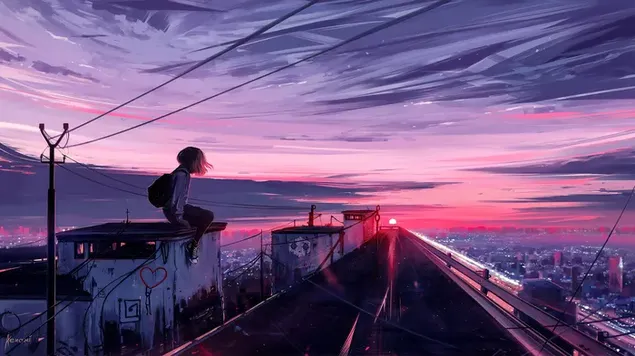

In [24]:
from IPython.display import display

print("Selected Image:")
display(image)

Step 17: Final Project Test

       AI IMAGE CAPTION GENERATOR - FINAL TEST

Image:


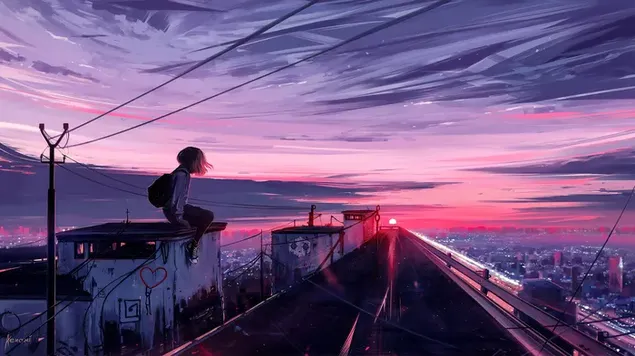


Available Caption Styles:
1. Short
2. Professional
3. Creative

Project Status: READY
AI Caption Generation: ENABLED
Hashtag Generation: ENABLED

              PROJECT COMPLETED


In [25]:
print("=" * 60)
print("       AI IMAGE CAPTION GENERATOR - FINAL TEST")
print("=" * 60)

print("\nImage:")
display(image)

print("\nAvailable Caption Styles:")
print("1. Short")
print("2. Professional")
print("3. Creative")

print("\nProject Status: READY")
print("AI Caption Generation: ENABLED")
print("Hashtag Generation: ENABLED")

print("\n" + "=" * 60)
print("              PROJECT COMPLETED")
print("=" * 60)